In [1]:
import torch
print(f"Torch version: {torch.__version__}")
from torch import nn
from torch.nn import functional as F
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
import numpy as np
from scipy.ndimage import rotate, gaussian_filter, binary_fill_holes, binary_closing
import torchvision
import os
import random
from torch.utils.data import Dataset
import cv2
from imutils import paths
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from torch.optim import Adam
from torchvision import transforms
import glob
from torchvision import transforms as T

Torch version: 2.2.2


In [22]:
def augment(im, ma, croprange = 0.7, thres = 0.005):
    #Gets as an input the image and mask tensors which will be transformed
    #Remember they come in with one extra dimension! We will give it back at the end

    #We want to turn them into numpy then back to torch
    
    ymean = 0
    while ymean<thres:
        img = im[0,:,:].numpy()
        mask = ma[0,:,:].numpy()
        ysize, xsize = img.shape
        
        #Do we rotate?
        rot = random.random()
        if rot>0.1:
            rotangle = random.randint(0, 360)
            img = rotate(img, rotangle)
            mask = rotate(mask, rotangle)
            mask = (mask>0.1).astype("float32")
            img = ((img-np.min(img))/np.amax(img)).astype("float32")
            
            cropfactor = random.uniform(croprange, 0.8)
            newsize = int(xsize*cropfactor/2)
            croppos = random.randint(newsize, xsize-newsize)
            cropimg = img[croppos-newsize:croppos+newsize,croppos-newsize:croppos+newsize]
            cropmask = mask[croppos-newsize:croppos+newsize,croppos-newsize:croppos+newsize]
            #Now resize and keep on going!
            img = cv2.resize(cropimg, dsize=(ysize, xsize), interpolation=cv2.INTER_CUBIC)
            mask = cv2.resize(cropmask, dsize=(ysize, xsize), interpolation=cv2.INTER_CUBIC)
            mask = gaussian_filter(mask, sigma =2)
        #Do we flip from side to side?
        flipright = random.random()
        if flipright>0.5:
            img = np.flip(img,axis=1)
            mask = np.flip(mask,axis=1)
            
        #Do we flip upside down?
        flipup = random.random()
        if flipup>0.5:            
            img = np.flip(img,axis=0)
            mask = np.flip(mask,axis=0)
        ymean = np.mean(mask)
        


    #Turn back to tensors with same dimensions and return!
    
    imgten = torch.tensor(img.copy())
    imgten= imgten.unsqueeze(0)
    maskten = torch.tensor(mask.copy())
    maskten= maskten.unsqueeze(0)
    
    return imgten,maskten

In [43]:
#This seems clearer so with all defined let´s try
#central path:
mainpath = r''
# base path of the dataset
DATASET_PATH = os.path.join(mainpath,"dataset", "train")

# define the path to the images and masks dataset
IMAGE_DATASET_PATH = os.path.join(DATASET_PATH, "images")
MASK_DATASET_PATH = os.path.join(DATASET_PATH, "masks")

# define the test split
TEST_SPLIT = 0.20

PIN_MEMORY = True if DEVICE == "cuda" else False

TRAIN_BATCH_SIZE = 16
VALID_BATCH_SIZE = 16

NUM_CHANNELS = 1
NUM_CLASSES = 1

INIT_LR = 0.0001
NUM_EPOCHS = 200 #can be increased to 1000 for example if 200 is not enough, if test loss start to rise then the training should be stopped as it is done

INPUT_IMAGE_WIDTH = 512
INPUT_IMAGE_HEIGHT = 512

THRESHOLD = 0.5

# define the path to the base output directory
BASE_OUTPUT = os.path.join(mainpath,"output")

MODEL_PATH = os.path.join(BASE_OUTPUT, "unet_tgs_salt.pth")
PLOT_PATH = os.path.sep.join([BASE_OUTPUT, "plot.png"])
TEST_PATHS = os.path.sep.join([BASE_OUTPUT, "test_paths.txt"])

[INFO] saving testing image paths...
[INFO] found 25 examples in the training set...
[INFO] found 25 examples in the test set...
[INFO] training the network...


  0%|                                                  | 0/1000 [00:00<?, ?it/s]

[INFO] EPOCH: 1/1000
Train loss: 1.527517, Test loss: 1.3017


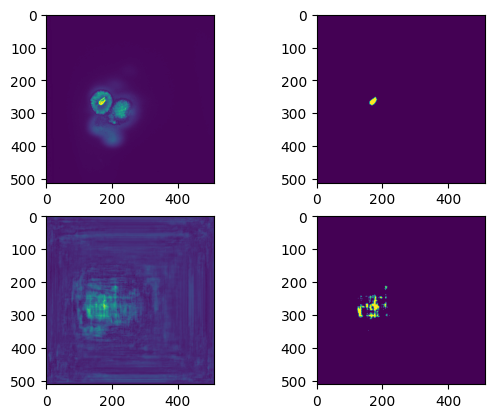

  0%|                                       | 2/1000 [01:16<10:40:42, 38.52s/it]

[INFO] EPOCH: 2/1000
Train loss: 1.490592, Test loss: 1.3606


  0%|                                       | 3/1000 [01:54<10:35:20, 38.24s/it]

[INFO] EPOCH: 3/1000
Train loss: 1.446402, Test loss: 1.3334


  0%|▏                                      | 4/1000 [02:31<10:25:07, 37.66s/it]

...

[INFO] EPOCH: 8/1000
Train loss: 1.358554, Test loss: 1.2369


  1%|▎                                      | 9/1000 [05:43<10:38:21, 38.65s/it]

[INFO] EPOCH: 9/1000
Train loss: 1.346949, Test loss: 1.2206


  1%|▍                                     | 10/1000 [06:19<10:23:45, 37.80s/it]

[INFO] EPOCH: 10/1000
Train loss: 1.334330, Test loss: 1.2115
[INFO] EPOCH: 11/1000
Train loss: 1.325001, Test loss: 1.2071


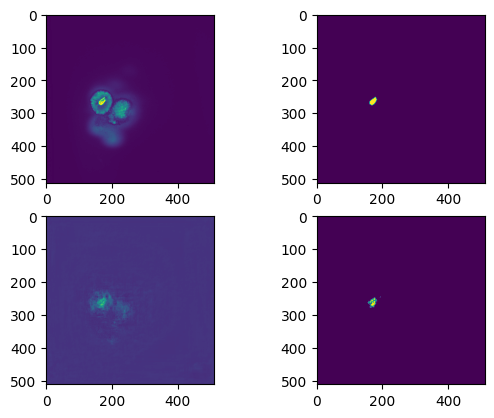

  1%|▍                                     | 12/1000 [07:38<10:38:01, 38.75s/it]

[INFO] EPOCH: 12/1000
Train loss: 1.323741, Test loss: 1.2035


  1%|▍                                     | 13/1000 [08:21<10:55:41, 39.86s/it]

[INFO] EPOCH: 13/1000
Train loss: 1.311364, Test loss: 1.1951


  1%|▌                                     | 14/1000 [09:00<10:50:06, 39.56s/it]

...

[INFO] EPOCH: 18/1000
Train loss: 1.286516, Test loss: 1.1733


  2%|▋                                     | 19/1000 [12:11<10:27:34, 38.38s/it]

[INFO] EPOCH: 19/1000
Train loss: 1.282816, Test loss: 1.1722


  2%|▊                                     | 20/1000 [12:52<10:39:17, 39.14s/it]

[INFO] EPOCH: 20/1000
Train loss: 1.280981, Test loss: 1.1685
[INFO] EPOCH: 21/1000
Train loss: 1.274920, Test loss: 1.1675


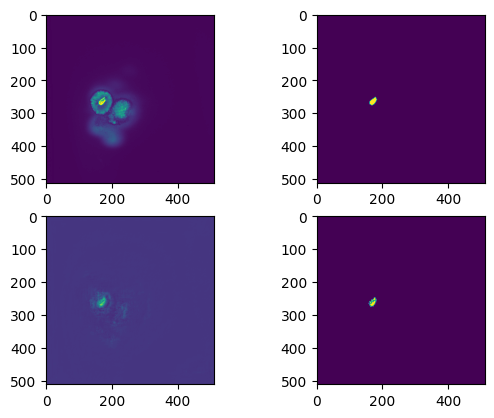

  2%|▊                                     | 22/1000 [14:12<10:46:05, 39.64s/it]

[INFO] EPOCH: 22/1000
Train loss: 1.270284, Test loss: 1.1653


  2%|▊                                     | 23/1000 [14:59<11:23:01, 41.95s/it]

[INFO] EPOCH: 23/1000
Train loss: 1.268970, Test loss: 1.1627


  2%|▉                                     | 24/1000 [15:36<10:58:11, 40.46s/it]

...

[INFO] EPOCH: 28/1000
Train loss: 1.256673, Test loss: 1.1533


  3%|█                                     | 29/1000 [18:49<10:32:44, 39.10s/it]

[INFO] EPOCH: 29/1000
Train loss: 1.254773, Test loss: 1.1517


  3%|█▏                                    | 30/1000 [19:30<10:45:17, 39.91s/it]

[INFO] EPOCH: 30/1000
Train loss: 1.253595, Test loss: 1.1508
[INFO] EPOCH: 31/1000
Train loss: 1.251413, Test loss: 1.1491


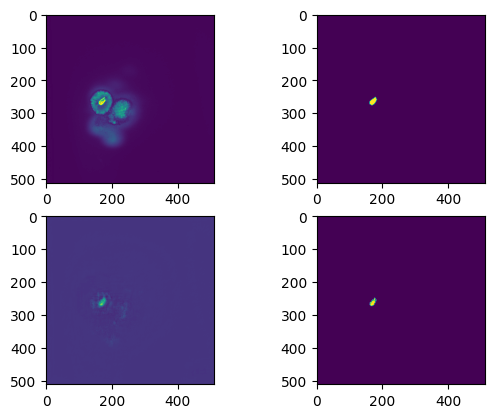

  3%|█▏                                    | 32/1000 [20:50<10:39:54, 39.66s/it]

[INFO] EPOCH: 32/1000
Train loss: 1.246002, Test loss: 1.1482


  3%|█▎                                    | 33/1000 [21:27<10:29:56, 39.09s/it]

[INFO] EPOCH: 33/1000
Train loss: 1.249841, Test loss: 1.1477


  3%|█▎                                    | 34/1000 [22:05<10:22:49, 38.68s/it]

...

[INFO] EPOCH: 38/1000
Train loss: 1.238279, Test loss: 1.1437


  4%|█▍                                    | 39/1000 [25:22<10:32:23, 39.48s/it]

[INFO] EPOCH: 39/1000
Train loss: 1.240848, Test loss: 1.1426


  4%|█▌                                    | 40/1000 [26:00<10:23:56, 39.00s/it]

[INFO] EPOCH: 40/1000
Train loss: 1.237762, Test loss: 1.1413
[INFO] EPOCH: 41/1000
Train loss: 1.237272, Test loss: 1.1402


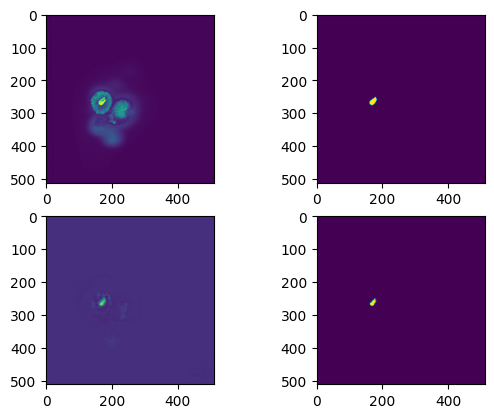

  4%|█▌                                    | 42/1000 [27:23<10:45:44, 40.44s/it]

[INFO] EPOCH: 42/1000
Train loss: 1.236296, Test loss: 1.1392


  4%|█▋                                    | 43/1000 [28:02<10:36:35, 39.91s/it]

[INFO] EPOCH: 43/1000
Train loss: 1.228310, Test loss: 1.1387


  4%|█▋                                    | 44/1000 [28:43<10:40:51, 40.22s/it]

...

[INFO] EPOCH: 48/1000
Train loss: 1.227379, Test loss: 1.1322


  5%|█▊                                    | 49/1000 [32:05<10:39:12, 40.33s/it]

[INFO] EPOCH: 49/1000
Train loss: 1.224370, Test loss: 1.1316


  5%|█▉                                    | 50/1000 [32:41<10:21:57, 39.28s/it]

[INFO] EPOCH: 50/1000
Train loss: 1.223645, Test loss: 1.1303
[INFO] EPOCH: 51/1000
Train loss: 1.222057, Test loss: 1.1297


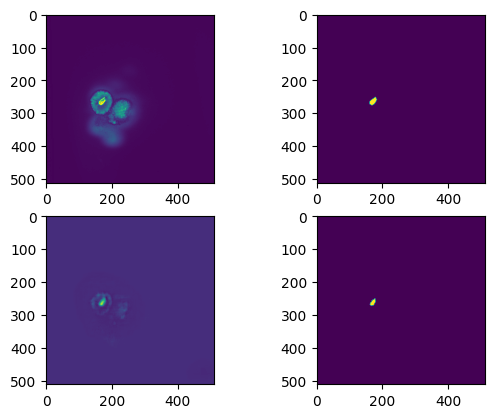

  5%|█▉                                    | 52/1000 [34:00<10:22:30, 39.40s/it]

[INFO] EPOCH: 52/1000
Train loss: 1.216684, Test loss: 1.1289


  5%|██                                    | 53/1000 [34:38<10:12:35, 38.81s/it]

[INFO] EPOCH: 53/1000
Train loss: 1.218795, Test loss: 1.1276


  5%|██                                    | 54/1000 [35:15<10:04:33, 38.34s/it]

...

[INFO] EPOCH: 58/1000
Train loss: 1.207556, Test loss: 1.1228


  6%|██▏                                   | 59/1000 [38:33<10:19:18, 39.49s/it]

[INFO] EPOCH: 59/1000
Train loss: 1.210478, Test loss: 1.1209


  6%|██▎                                   | 60/1000 [39:14<10:28:18, 40.10s/it]

[INFO] EPOCH: 60/1000
Train loss: 1.212022, Test loss: 1.1198
[INFO] EPOCH: 61/1000
Train loss: 1.205084, Test loss: 1.1199


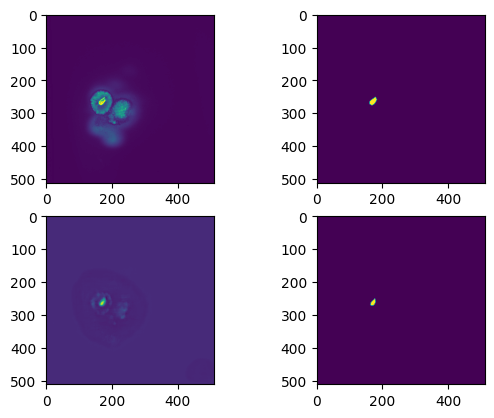

  6%|██▎                                   | 62/1000 [40:32<10:18:10, 39.54s/it]

[INFO] EPOCH: 62/1000
Train loss: 1.205062, Test loss: 1.1185


  6%|██▍                                   | 63/1000 [41:15<10:31:32, 40.44s/it]

[INFO] EPOCH: 63/1000
Train loss: 1.205520, Test loss: 1.1173


  6%|██▍                                   | 64/1000 [41:56<10:33:02, 40.58s/it]

...

[INFO] EPOCH: 68/1000
Train loss: 1.198336, Test loss: 1.1139


  7%|██▌                                   | 69/1000 [45:24<10:52:26, 42.05s/it]

[INFO] EPOCH: 69/1000
Train loss: 1.195556, Test loss: 1.1124


  7%|██▋                                   | 70/1000 [46:05<10:46:12, 41.69s/it]

[INFO] EPOCH: 70/1000
Train loss: 1.190666, Test loss: 1.1121
[INFO] EPOCH: 71/1000
Train loss: 1.196282, Test loss: 1.1105


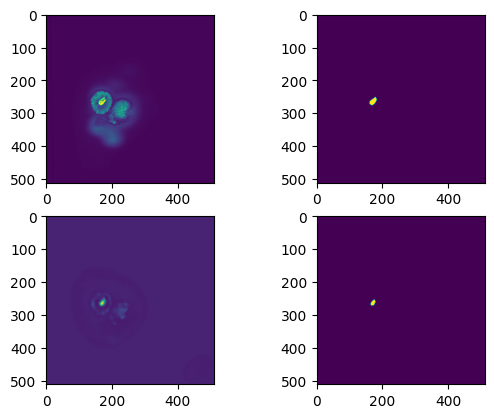

  7%|██▋                                   | 72/1000 [47:25<10:29:23, 40.69s/it]

[INFO] EPOCH: 72/1000
Train loss: 1.193608, Test loss: 1.1108


  7%|██▊                                   | 73/1000 [48:03<10:16:01, 39.87s/it]

[INFO] EPOCH: 73/1000
Train loss: 1.193640, Test loss: 1.1090


  7%|██▊                                   | 74/1000 [48:43<10:17:37, 40.02s/it]

...

[INFO] EPOCH: 78/1000
Train loss: 1.188396, Test loss: 1.1051


  8%|███                                   | 79/1000 [51:57<10:02:44, 39.27s/it]

[INFO] EPOCH: 79/1000
Train loss: 1.183900, Test loss: 1.1035


  8%|███                                   | 80/1000 [52:39<10:14:31, 40.08s/it]

[INFO] EPOCH: 80/1000
Train loss: 1.186285, Test loss: 1.1028
[INFO] EPOCH: 81/1000
Train loss: 1.185545, Test loss: 1.1011


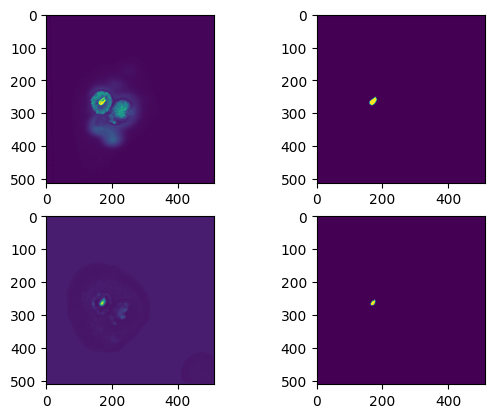

  8%|███                                   | 82/1000 [53:59<10:10:22, 39.89s/it]

[INFO] EPOCH: 82/1000
Train loss: 1.178724, Test loss: 1.1004


  8%|███▏                                   | 83/1000 [54:36<9:58:24, 39.15s/it]

[INFO] EPOCH: 83/1000
Train loss: 1.182455, Test loss: 1.0994


  8%|███▎                                   | 84/1000 [55:14<9:49:59, 38.65s/it]

...

[INFO] EPOCH: 88/1000
Train loss: 1.178834, Test loss: 1.0947


  9%|███▍                                  | 89/1000 [58:35<10:08:00, 40.04s/it]

[INFO] EPOCH: 89/1000
Train loss: 1.177128, Test loss: 1.0928


  9%|███▍                                  | 90/1000 [59:14<10:03:54, 39.82s/it]

[INFO] EPOCH: 90/1000
Train loss: 1.168721, Test loss: 1.0922
[INFO] EPOCH: 91/1000
Train loss: 1.171598, Test loss: 1.0915


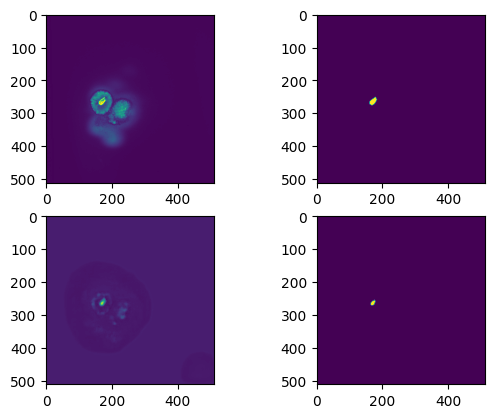

  9%|███▎                                | 92/1000 [1:00:36<10:12:13, 40.46s/it]

[INFO] EPOCH: 92/1000
Train loss: 1.172229, Test loss: 1.0900


  9%|███▎                                | 93/1000 [1:01:17<10:13:23, 40.58s/it]

[INFO] EPOCH: 93/1000
Train loss: 1.169615, Test loss: 1.0896


  9%|███▍                                | 94/1000 [1:01:56<10:04:46, 40.05s/it]

[INFO] EPOCH: 94/1000
Train loss: 1.172771, Test loss: 1.0887


  9%|███▍                                 | 94/1000 [1:02:01<9:57:45, 39.59s/it]


KeyboardInterrupt: 

In [44]:
# 1. Use a unique name for the transformation object
data_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((INPUT_IMAGE_HEIGHT, INPUT_IMAGE_WIDTH)),
    T.ToTensor()
])

# 2. Define a placeholder for augment if you haven't yet
def augment(image, mask):
    return image, mask

# 3. Use the glob paths we discussed to find your .tif files
imagePaths = sorted(glob.glob(os.path.join(IMAGE_DATASET_PATH, "*.tif")))
maskPaths = sorted(glob.glob(os.path.join(MASK_DATASET_PATH, "*.tif")))

class SegmentationDataset(Dataset):
    def __init__(self, imagePaths, maskPaths, transforms):
        self.imagePaths = imagePaths
        self.maskPaths = maskPaths
        self.transforms = transforms

    def __len__(self):
        return len(self.imagePaths)

    def __getitem__(self, idx):
        # 1. Load data
        # IMREAD_UNCHANGED is good for .tif files
        image = cv2.imread(self.imagePaths[idx], cv2.IMREAD_UNCHANGED)
        mask = cv2.imread(self.maskPaths[idx], cv2.IMREAD_UNCHANGED)

        # 2. Normalize Image: Keep as float32 [0, 1]
        image = image.astype("float32")
        image = (image - image.min()) / (image.max() - image.min() + 1e-8) # Scales exactly to [0, 1]
        
        # 3. FIX MASK: Convert to Binary (0.0 and 1.0)
        # Any pixel > 0 becomes 1. This prevents the "invisible mask" issue.
        mask = (mask > 0).astype("float32") 

        # 4. Apply Transforms
        if self.transforms is not None:
            # Note: If your transforms include Random Rotation/Flip, 
            # you usually need to apply the SAME random seed to both 
            # so the mask stays aligned with the image.
            image = self.transforms(image)
            mask = self.transforms(mask)

        # 5. Ensure Correct Dimensions
        # If your image is 3-channel but you want 1-channel for U-Net:
        if image.shape[0] > 1:
            image = image[0, :, :].unsqueeze(0)
            
        # Ensure mask is [1, H, W]
        if len(mask.shape) == 2:
            mask = torch.from_numpy(mask).unsqueeze(0)
        elif isinstance(mask, torch.Tensor) and mask.ndimension() == 2:
            mask = mask.unsqueeze(0)

        return (image, mask)

imagePaths = sorted(list(paths.list_images(IMAGE_DATASET_PATH)))
maskPaths = sorted(list(paths.list_images(MASK_DATASET_PATH)))
# partition the data into training and testing splits using 85% of
# the data for training and the remaining 15% for testing
split = train_test_split(imagePaths, maskPaths,
	test_size=0.5, random_state=42) #test_size=TEST_SPLIT
# unpack the data split
(trainImages, testImages) = split[:2]
(trainMasks, testMasks) = split[2:]
# write the testing image paths to disk so that we can use then
# when evaluating/testing our model
print("[INFO] saving testing image paths...")
f = open(TEST_PATHS, "w")
f.write("\n".join(testImages))
f.close()

# define transformations
trainDS = SegmentationDataset(imagePaths=trainImages, maskPaths=trainMasks, transforms=data_transforms)
testDS = SegmentationDataset(imagePaths=testImages, maskPaths=testMasks, transforms=data_transforms)

print(f"[INFO] found {len(trainDS)} examples in the training set...")
print(f"[INFO] found {len(testDS)} examples in the test set...")


def dice_loss(input, target):
    input = torch.sigmoid(input)
    smooth = 1.0
    iflat = input.view(-1)
    tflat = target.view(-1)
    intersection = (iflat * tflat).sum()
    return ((2.0 * intersection + smooth) / (iflat.sum() + tflat.sum() + smooth))

# from https://www.kaggle.com/rishabhiitbhu/unet-with-resnet34-encoder-pytorch

class FocalLoss(nn.Module):
    def __init__(self, gamma):
        super().__init__()
        self.gamma = gamma

    def forward(self, input, target):
        if not (target.size() == input.size()):
            raise ValueError("Target size ({}) must be the same as input size ({})"
                             .format(target.size(), input.size()))
        max_val = (-input).clamp(min=0)
        loss = input - input * target + max_val + \
            ((-max_val).exp() + (-input - max_val).exp()).log()
        invprobs = F.logsigmoid(-input * (target * 2.0 - 1.0))
        loss = (invprobs * self.gamma).exp() * loss
        return loss.mean()

class MixedLoss(nn.Module):
    def __init__(self, alpha, gamma):
        super().__init__()
        self.alpha = alpha
        self.focal = FocalLoss(gamma)

    def forward(self, input, target):
        # Linear Dice loss: 1 - dice_score
        dice = dice_loss(input, target)
        loss = self.alpha * self.focal(input, target) + (1 - dice)
        return loss
        #loss = self.alpha*self.focal(input, target) - torch.log(dice_loss(input, target))
        #return loss.mean()


model = smp.Unet(
    encoder_name='resnet18',   # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=1,                      # model output channels (number of classes in your dataset)
)


def norm(array):
    valmax = np.amax(array)
    valmin = np.amin(array)
    normed = (array-valmin)/(valmax-valmin)
    return normed

#Let´s do a training loop:

def matplotlib_imshow(img, one_channel=False):
    fig,ax = plt.subplots(figsize=(10,6))
    ax.imshow(img.permute(1,2,0).numpy())

x, y = trainDS[0]
x.shape
#matplotlib_imshow(pred.cpu().detach())

(x, y) = (x.to(DEVICE), y.to(DEVICE))


model = model.to(DEVICE)
lossfunc=MixedLoss(0.5, 0.5)


# initialize a dictionary to store training history
H = {"train_loss": [], "test_loss": []}

BATCH_SIZE = 16 #32
THRES = 0.001
opt = Adam(model.parameters(), lr=INIT_LR)
print("[INFO] training the network...")
startTime = time.time()
for e in tqdm(range(NUM_EPOCHS)):
    # set the model in training mode
    model.train()
    # initialize the total training and validation loss
    totalTrainLoss = 0
    totalTestLoss = 0
    #Distribute the training set into batches
    allnums = list(range(0, len(trainDS)))
    numbatch = int(len(trainDS)/BATCH_SIZE)
    # loop over the training set
    BATCHlist = []
    for b in range(numbatch):
        templist = []
        while len(templist)<BATCH_SIZE:
            templist.append(allnums.pop(random.randint(0,len(allnums)-1)))
        BATCHlist.append(templist)
    BATCHlist.append(allnums)
    
    for b in range(len(BATCHlist)-1):
        currentbatch = BATCHlist[b]
        batchloss = 0
        batchcount= 0
        for i in range(len(currentbatch)):
            #end the input to the device
            x,y = trainDS[currentbatch[i]]
            ymean = torch.mean(y)
            if ymean < THRES:
                continue
            x,y= augment(x,y)
            (x, y) = (x.to(DEVICE), y.to(DEVICE))
            # perform a forward pass and calculate the training loss
            while len(x.shape)<4:
                x = x.unsqueeze(0)
            pred = model(x)
            pred = pred.squeeze(0)
            loss = lossfunc(pred, y)
            batchloss += loss
            batchcount += 1
        
        batchloss = batchloss/batchcount
        # first, zero out any previously accumulated gradients, then
        # perform backpropagation, and then update model parameters
        opt.zero_grad()
        batchloss.backward()
        opt.step()
        # add the loss to the total training loss so far
        totalTrainLoss += batchloss
	# switch off autograd
    with torch.no_grad():
        # set the model in evaluation mode
        model.eval()
        # loop over the validation set
        for i in range(len(testDS)):
            x,y = testDS[i]
            ymean = torch.mean(y)
            if ymean < THRES:
                continue
            x,y= augment(x,y)
            # send the input to the device
            (x, y) = (x.to(DEVICE), y.to(DEVICE))
            while len(x.shape)<4:
                x = x.unsqueeze(0)
            while len(y.shape)<4:
                y = y.unsqueeze(0)
            # make the predictions and calculate the validation loss
            pred = model(x)
            
            totalTestLoss += lossfunc(pred, y)
    # calculate the average training and validation loss
    avgTrainLoss = totalTrainLoss / (len(trainDS)//BATCH_SIZE)
    avgTestLoss = totalTestLoss / len(testDS)
    # update our training history
    H["train_loss"].append(avgTrainLoss.cpu().detach().numpy())
    H["test_loss"].append(avgTestLoss.cpu().detach().numpy())
    # print the model training and validation information
    print("[INFO] EPOCH: {}/{}".format(e + 1, NUM_EPOCHS))
    print("Train loss: {:.6f}, Test loss: {:.4f}".format(
    		avgTrainLoss, avgTestLoss))
    
    if e%10 == 0:
        x,y =testDS[4]
        ymean = torch.mean(y)
        if ymean < THRES:
            continue
        x,y= augment(x,y)
        
        (x, y) = (x.to(DEVICE), y.to(DEVICE))
        model.eval()
        while len(x.shape)<4:
            x = x.unsqueeze(0)
        while len(y.shape)<4:
            y = y.unsqueeze(0)
        # turn off gradient tracking
        with torch.no_grad():
            pred = model(x)
            loss = lossfunc(pred, y)
        
        predim = pred.cpu().detach().numpy()
        yim = y.cpu().detach().numpy()
        xim = x.cpu().detach().numpy()
        prednorm = norm(predim[0,0,:,:])
        plt.figure()
        plt.subplot(2,2,1)
        plt.imshow(xim[0,0,:,:])
        plt.subplot(2,2,2)
        plt.imshow(yim[0,0,:,:])
        plt.subplot(2,2,3)
        plt.imshow(predim[0,0,:,:])
        plt.subplot(2,2,4)
        plt.imshow(prednorm>THRESHOLD)
        plt.show()
        
    if (e + 1) % 50 == 0:
        save_path = f'/Users/marchenk/Desktop/Model3/ModelVer07072023/checkpoint_epoch_{e+1}.pth'
        torch.save(model.state_dict(), save_path)
        print(f"[INFO] Checkpoint saved: {save_path}")

#Some model testing:
    
plt.style.use("ggplot")
plt.figure()
plt.plot(H["train_loss"], label="train_loss")
plt.plot(H["test_loss"], label="test_loss")
plt.title("Training Loss on Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend(loc="lower left")
plt.savefig(PLOT_PATH)

torch.save(model.state_dict(), r'/Users/marchenk/Desktop/Model3/ModelVer07072023/modlparam.zip')

In [49]:
from skimage.filters import threshold_otsu

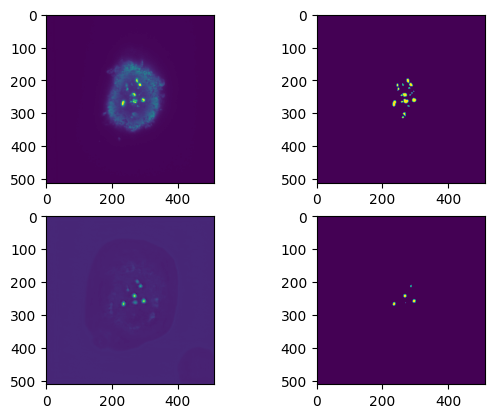

tensor(1.1916)


In [50]:
def testmodel(i):
    x,y =testDS[i]
    (x, y) = (x.to(DEVICE), y.to(DEVICE))
    model.eval()
    while len(x.shape)<4:
        x = x.unsqueeze(0)
    while len(y.shape)<4:
        y = y.unsqueeze(0)
    # turn off gradient tracking
    with torch.no_grad():
        pred = model(x)
        loss = lossfunc(pred, y)

    predim = pred.cpu().detach().numpy()
    yim = y.cpu().detach().numpy()
    xim = x.cpu().detach().numpy()
    prednorm = norm(predim[0,0,:,:])
    #THRES = threshold_otsu(prednorm)*1.2
    
    plt.figure()
    plt.subplot(2,2,1)
    plt.imshow(xim[0,0,:,:])
    plt.subplot(2,2,2)
    plt.imshow(yim[0,0,:,:])
    plt.subplot(2,2,3)
    plt.imshow(predim[0,0,:,:])
    plt.subplot(2,2,4)
    plt.imshow(prednorm>THRESHOLD)
    plt.show()
    
    print(loss)
    return

testmodel(10)